# AI-Powered Intelligent Hiring Tool: EDA and Preprocessing

## Objective
This notebook performs Exploratory Data Analysis (EDA) and preprocessing on the resume dataset used for the AI-Powered Intelligent Hiring Tool.

The goal is to understand the dataset structure, analyze resume categories, clean textual data, and prepare the dataset for Machine Learning and Deep Learning models.

### Key Tasks
- Load and inspect dataset
- Perform Exploratory Data Analysis (EDA)
- Clean resume text
- Generate additional features
- Encode labels for classification
- Save cleaned dataset

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.preprocessing import LabelEncoder
from google.colab import files

In [3]:
df = pd.read_json('/content/resumes_dataset.jsonl', lines=True)

# Basic Dataset Inspection

In this section, we inspect:
- Number of rows and columns
- Sample records
- Data types
- Missing values

This helps us understand dataset quality and structure.

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (3500, 12)


,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ResumeID    3500 non-null   object
 1   Category    3500 non-null   object
 2   Name        3500 non-null   object
 3   Email       3500 non-null   object
 4   Phone       3500 non-null   object
 5   Location    3500 non-null   object
 6   Summary     3500 non-null   object
 7   Skills      3500 non-null   object
 8   Experience  3500 non-null   object
 9   Education   3500 non-null   object
 10  Text        3500 non-null   object
 11  Source      3500 non-null   object
dtypes: object(12)
memory usage: 328.3+ KB


In [6]:
df.columns

Index(['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary',
       'Skills', 'Experience', 'Education', 'Text', 'Source'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
ResumeID,0
Category,0
Name,0
Email,0
Phone,0
Location,0
Summary,0
Skills,0
Experience,0
Education,0


# Exploratory Data Analysis (EDA)

We analyze the distribution of resumes across different job categories.

### Purpose
- Understand class distribution
- Identify imbalance across roles
- Gain insights into dataset composition

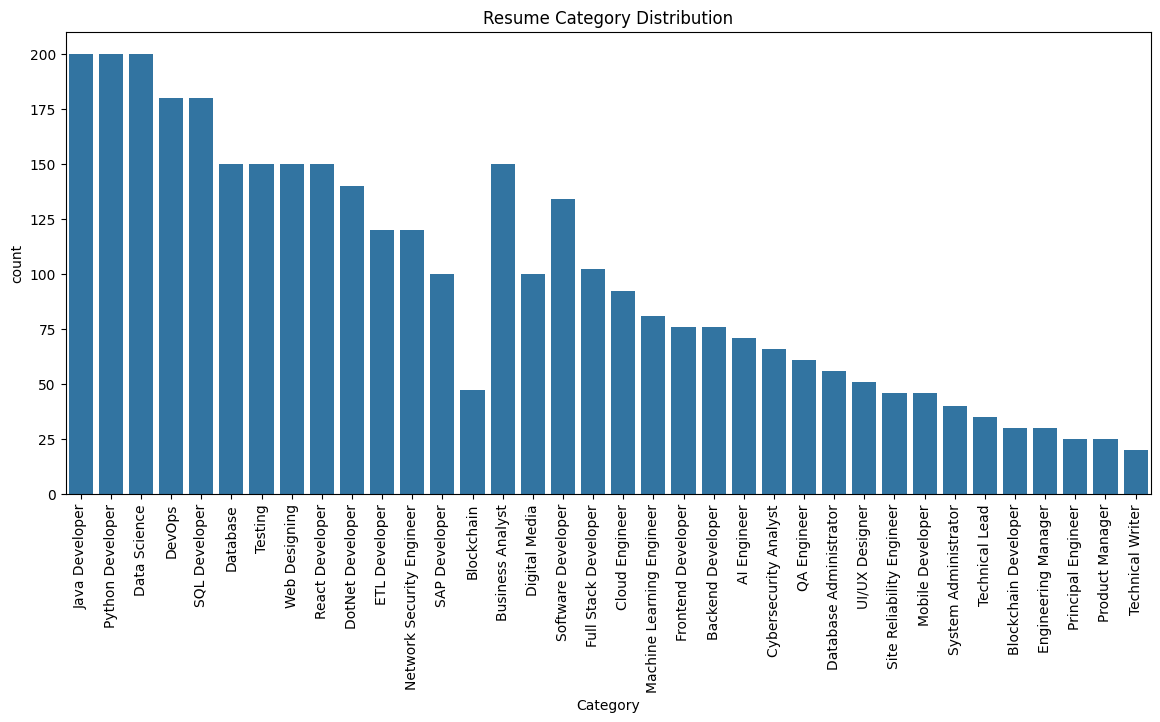

In [8]:
plt.figure(figsize=(14,6))
sns.countplot(x='Category', data=df)
plt.xticks(rotation=90)
plt.title("Resume Category Distribution")
plt.show()

In [9]:
df['Category'].value_counts()

,count
Category,
Java Developer,200
Python Developer,200
Data Science,200
DevOps,180
SQL Developer,180
Database,150
Testing,150
Web Designing,150
React Developer,150


# Resume Text Inspection

Before preprocessing, we examine raw resume text.

This helps identify:
- Noise
- Formatting issues
- Special characters
- Unnecessary tokens

In [10]:
print(df['Text'].iloc[0][:3000])

jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior java developertech lead 2014 current synnex corporation tracy ca java developer agile scrum team javascript java develop customer facing internal web applications underlying component applications wrote maintainable extensible code team environment implemented designs including experimentation multiple iterations system administrator 102011 112013 mantech international corporation joint base mcguire nj technical lead system administrator oracle ebusiness suite erp application mentored technical staff java developerscada system admin 092008 102011 big lots anniston al developed maintained internal web applications managed scada system wind energy business business analyst 2008 092008 john deere 

# Text Cleaning and Preprocessing

Resume text is cleaned to improve model performance.

### Cleaning Steps
- Convert text to lowercase
- Remove URLs
- Remove numbers
- Remove punctuation
- Remove extra spaces

This produces standardized text suitable for NLP processing.

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [12]:
df['clean_text'] = df['Text'].apply(clean_text)

In [13]:
df[['Text', 'clean_text']].head()

,Text,clean_text
0,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...
1,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer linkedincomi...
2,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire resumesampleexamplecom montgome...
3,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire resumesampleexamplecom montgome...
4,jessica claire 100 montgomery st 10th floor xx...,jessica claire montgomery st th floor xxx resu...


# Feature Engineering

Additional features are created to improve analysis.

### Features Generated
- Cleaned Resume Text
- Resume Length

Resume length can help analyze content distribution and resume complexity.

In [14]:
df['resume_length'] = df['clean_text'].apply(len)

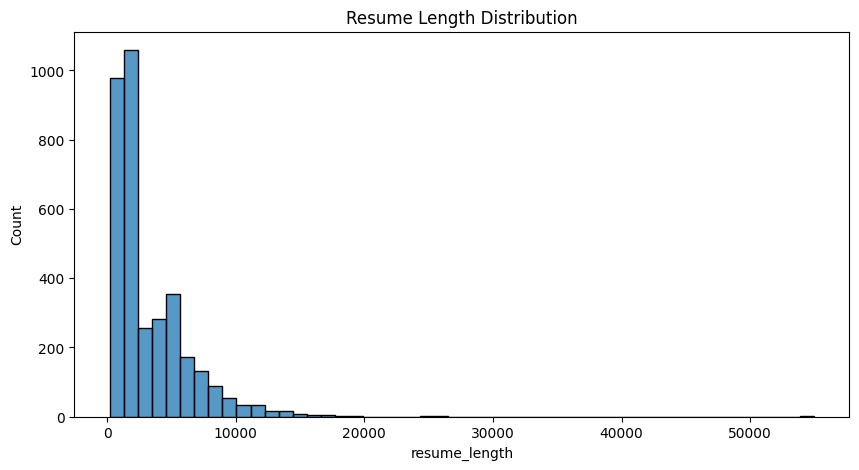

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['resume_length'], bins=50)
plt.title("Resume Length Distribution")
plt.show()

# Label Encoding

Machine Learning models require numerical labels.

In this section, categorical job roles are converted into numerical labels using Label Encoding.

### Example
- Data Science → 0
- Python Developer → 1
- Java Developer → 2

In [16]:
encoder = LabelEncoder()
df['category_encoded'] = encoder.fit_transform(df['Category'])

In [17]:
mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))
mapping

{'AI Engineer': 0,
 'Backend Developer': 1,
 'Blockchain': 2,
 'Blockchain Developer': 3,
 'Business Analyst': 4,
 'Cloud Engineer': 5,
 'Cybersecurity Analyst': 6,
 'Data Science': 7,
 'Database': 8,
 'Database Administrator': 9,
 'DevOps': 10,
 'Digital Media': 11,
 'DotNet Developer': 12,
 'ETL Developer': 13,
 'Engineering Manager': 14,
 'Frontend Developer': 15,
 'Full Stack Developer': 16,
 'Java Developer': 17,
 'Machine Learning Engineer': 18,
 'Mobile Developer': 19,
 'Network Security Engineer': 20,
 'Principal Engineer': 21,
 'Product Manager': 22,
 'Python Developer': 23,
 'QA Engineer': 24,
 'React Developer': 25,
 'SAP Developer': 26,
 'SQL Developer': 27,
 'Site Reliability Engineer': 28,
 'Software Developer': 29,
 'System Administrator': 30,
 'Technical Lead': 31,
 'Technical Writer': 32,
 'Testing': 33,
 'UI/UX Designer': 34,
 'Web Designing': 35}

# Export Cleaned Dataset

After preprocessing, the cleaned dataset is saved for downstream tasks.

This dataset will be used in:
- Resume classification models
- Candidate-job matching
- Intelligent hiring pipeline

In [18]:
df.to_csv('/content/cleaned_resumes.csv', index=False)

In [19]:
files.download('/content/cleaned_resumes.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Summary

This notebook completed the data preparation stage of the AI-Powered Intelligent Hiring Tool.

### Completed Tasks
- Loaded and analyzed resume dataset
- Performed exploratory data analysis
- Cleaned resume text
- Generated useful features
- Encoded job categories
- Exported processed dataset

### Output
- Cleaned dataset ready for ML/DL model training

This prepared dataset is used in subsequent notebooks for model training and intelligent hiring tasks.